# Example 6: GNSS Sidelobe Pseudorange + Doppler + TDCP ODTS with an EKF

This tutorial turns the link-geometry products from Example 5 into an orbit-determination and time-synchronization problem. A lunar-orbiting receiver estimates its position, velocity, clock bias, clock drift, and solar-radiation-pressure coefficient using weak Earth-GNSS sidelobe signals.

The measurement model combines three observables:

$$
\rho_k = \|\mathbf r_{rx,k}-\mathbf r_{tx,k}\| + c\,b_k + \Delta_{rel,k}+\Delta_{plasma,k}+\epsilon_{\rho,k},
$$

the instantaneous Doppler (range rate), which constrains velocity and clock drift within a single epoch,

$$
\dot\rho_k = \frac{(\mathbf r_{rx,k}-\mathbf r_{tx,k})\cdot(\mathbf v_{rx,k}-\mathbf v_{tx,k})}{\|\mathbf r_{rx,k}-\mathbf r_{tx,k}\|} + c\,\dot b_k + \epsilon_{\dot\rho,k},
$$

and time-differenced carrier phase (TDCP), which approximately measures the change in range between consecutive epochs:

$$
\Delta\Phi_k \approx [\rho_k-\rho_{k-1}] + \epsilon_{\Delta\Phi,k}.
$$

Because TDCP references two epochs, the filter uses a stochastic-cloning UDU EKF: the augmented state carries both the current and previous receiver state so the TDCP Jacobian can be formed consistently. This is the main mathematical lesson of the notebook.

The workflow is staged:

1. precompute GNSS (GPS + Galileo) visibility, antenna gain, and $C/N_0$;
2. precompute plasmaspheric delay with GCPM/IRI2007 ray tracing on a coarse cadence and interpolate it to 1 Hz;
3. run the EKF and inspect orbit, clock, and SRP-coefficient errors.

Truth pseudoranges include the Sun's Shapiro delay and the GCPM/IRI2007 plasmaspheric delay. The filter models the (small, deterministic) Shapiro delay directly and cancels the first-order plasma delay with the dual-frequency ionosphere-free (L1+L5 / E1+E5a) combination rather than modeling the plasma explicitly; the residual is absorbed through pseudorange measurement-noise inflation. TDCP is single-frequency (L1) and, being deceptively precise, has its noise inflated past raw carrier precision so the EKF does not chase truth/filter dynamics mismatch as if it were real state error.

The precompute stages write CSV caches under `output/python_examples/ex6_gnss_odts_data/`. Delete that directory to regenerate all deterministic products.

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Make *this* repo's pylupnt import cleanly, regardless of a global PYTHONPATH (e.g. an
# `export PYTHONPATH=.../some-other/python` in ~/.zshrc) or a reverted Jupyter kernelspec.
# Walk up from the working dir to the repo root (the dir holding python/pylupnt/) and:
#   1. put its python/ first on sys.path so `import pylupnt` finds this build, and
#   2. pin LUPNT_DATA_PATH so pylupnt uses this repo's data and skips its bootstrap
#      download-on-import.
# This cell must run before any other pylupnt import (restart the kernel if it already ran). ---
for _base in [Path.cwd(), *Path.cwd().parents]:
    if (_base / "python" / "pylupnt" / "__init__.py").exists():
        _local_python = str((_base / "python").resolve())
        if _local_python in sys.path:
            sys.path.remove(_local_python)
        sys.path.insert(0, _local_python)
        if (_base / "data" / "LuPNT_data" / "ephemeris").is_dir():
            os.environ["LUPNT_DATA_PATH"] = str(
                (_base / "data" / "LuPNT_data").resolve()
            )
        break

import pylupnt as pnt

print(f"pylupnt loaded from: {pnt.__file__}")
assert hasattr(pnt, "LunarGnssODTSConfig"), (
    "Loaded a stale pylupnt without LunarGnssODTSConfig -- restart the kernel so this cell "
    "runs first, or rebuild this repo's bindings with `pixi run build-py`."
)

[00.00][PyLuPNT] Initializing


pylupnt loaded from: /Users/keidaiiiyama/Documents/sw_navlab/LuPNT/python/pylupnt/__init__.py


## 1. Simulation configuration

`LunarGnssODTSConfig` is the Python-facing configuration for the same C++ simulation engine used by LuPNT's staged GNSS filtering pipeline. It defines the truth ELFO, the filter's reduced dynamics model, receiver-clock process noise, GNSS link-budget settings, plasma-delay options, and EKF tuning.

A key tutorial point is that the filter is intentionally imperfect: truth includes higher-fidelity dynamics and media effects, while the estimator uses a simpler onboard-style model. The measurement covariance is therefore inflated beyond raw tracking precision so the EKF does not chase unmodeled dynamics or plasma delay as if they were real state error.

In [2]:
# The full configuration lives in `ex6_gnss_odts_config.py` and is shared with the
# standalone precompute script `ex6_precompute.py`. Both build the SAME config, which is
# essential: the C++ precompute cache is keyed on a fingerprint of the config, so the
# notebook only reuses the script's cached Stage 1/2 output when the configs match exactly.
# Edit that module to change the scenario (orbit, constellation, thresholds, tuning, ...).
from ex6_gnss_odts_config import (
    build_config,
    describe,
    DATA_DIR,
    OUTPUT_DIR,
    PLASMA_DELAY_DT_S,
)

cfg = build_config()
sim = pnt.LunarGnssODTSSimulation(cfg)
print(describe(cfg))

Configured 13.19-h run (~1 ELFO orbital period, 47475 s) at 1 Hz starting 2023-01-01T02:00:00
  TDCP on, SRP-coeff estimation on (truth Cr*A/m = 2.00e-3 m^2/kg)
  Pseudorange: ionosphere-free (L1+L5), C/N0 noise + filter inflation (PR 10 m, TDCP 50 mm)
  Tangent-altitude cutoff: PR >= 1000 m, TDCP >= 4000 m
  Constellation: GPS + Galileo, receiver antenna moongpsr, C/N0 gate 22/20 dB-Hz (acquisition/tracking)
  Plasma delay ray-traced every 120 s, interpolated to 1 Hz; progress every 10 rays
  EKF run progress every 1000 epochs (1000 s)
Data directory: /Users/keidaiiiyama/Documents/sw_navlab/LuPNT/output/python_examples/ex6_gnss_odts_data


## 2. Stage 1 & 2 — Precompute (run the script first!)

Stage 1 (link geometry) and Stage 2 (plasmaspheric ray tracing) are the slow part of this
example and are painful to run inside a notebook. **Run them once from a terminal:**

```bash
pixi run python ex6_precompute.py          # generate the cache (Stage 1 + Stage 2)
pixi run python ex6_precompute.py --force  # wipe and regenerate
```

That uses the exact same config as this notebook (both call
`ex6_gnss_odts_config.build_config`), so afterwards the two cells below are just fast cache
reads. `sim.precompute()` propagates the truth ELFO trajectory, builds the GPS+Galileo
constellation, solves visibility/light-time, and writes every tracked link to
`config.links_file`; the C++ side caches it by fingerprinting the config, so re-running is a
no-op once the script has produced it. (If you skip the script, the cells still work — they
just do the slow work in-notebook.)

In [3]:
t0 = time.time()
sim.precompute()
print(f"precompute() took {time.time() - t0:.1f} s")

links = pd.read_csv(cfg.links_file)
print(
    f"{len(links)} receiver-satellite-frequency links across "
    f"{links['epoch_index'].nunique()} epochs "
    f"({links.groupby('epoch_index').size().mean():.1f} links/epoch on average)"
)
links.head()

precompute() took 0.0 s[02.06][LunarGnssODTS] Using cached GNSS link precompute: /Users/keidaiiiyama/Documents/sw_navlab/LuPNT/output/python_examples/ex6_gnss_odts_data/precomputed_links.csv



462566 receiver-satellite-frequency links across 47475 epochs (9.7 links/epoch on average)


,link_id,epoch_index,t_tdb,t_utc,gnss_const_id,gnss_const,prn,frequency_id,frequency,rx_x_ecef_m,...,cn0_dbhz,ionosphere_plasma_delay_m,tecu,tec_delay_m,second_delay_m,third_delay_m,dist_bend_m,tec_delay_bend_m,max_sep_line_m,final_pos_err_m
0,0,0,7.258105e+08,725810400.0,0,GPS,16,0,L1,-5.218664e+07,...,23.523920,0,0,0,0,0,0,0,0,0
1,1,0,7.258105e+08,725810400.0,0,GPS,18,0,L1,-5.218664e+07,...,24.807172,0,0,0,0,0,0,0,0,0
2,2,0,7.258105e+08,725810400.0,0,GPS,23,0,L1,-5.218664e+07,...,22.460590,0,0,0,0,0,0,0,0,0
3,3,0,7.258105e+08,725810400.0,0,GPS,26,0,L1,-5.218664e+07,...,23.367584,0,0,0,0,0,0,0,0,0
4,4,0,7.258105e+08,725810400.0,0,GPS,31,0,L1,-5.218664e+07,...,34.691083,0,0,0,0,0,0,0,0,0


## 3. Stage 2 — Precompute Plasmaspheric Delay (GCPM/IRI2007 Ray Trace)

This mirrors `projects/GNSS_Filtering/precompute_delays.py`: `pnt.trace_ray` integrates the
GCPM/IRI2007 electron-density model along the transmitter-receiver line of sight and returns
the total electron content (TEC) delay plus higher-order (2nd/3rd) ionospheric terms.

Ray tracing is the slow step (one trace per link), and at 1 Hz over a full orbital period
there are far too many links to trace directly. Instead, this stage **ray-traces only
"anchor" epochs on a `PLASMA_DELAY_DT_S` = 120 s cadence and linearly interpolates each
satellite-frequency link's delay in time to the 1 Hz schedule** — the receiver's sidelobe
geometry, and hence the plasmaspheric path, varies slowly enough over two minutes for
linear interpolation to be accurate. This cuts the trace count by roughly the cadence
factor (~120×). A satellite whose entire pass falls between two anchors (shorter than the
cadence) has no anchor to interpolate from and is traced directly as a fallback, so a real
delay is never silently zeroed.

The remaining anchor traces are **run in parallel across processes** with a
`multiprocessing` **fork** pool (`N_DELAY_WORKERS` = `os.cpu_count()`). Ray tracing is
CPU-bound and each trace is independent, so this scales ~linearly with cores. A *fork*
context is used deliberately: each worker then inherits the parent's already-configured
`rt_config` and `pnt` module, and the notebook-scope worker function resolves in the child
(the default *spawn* start method on some platforms cannot pickle functions defined in a
notebook cell). Results are cached to `config.delays_file` — which stores a delay for
*every* 1 Hz link, so the C++ engine reads it unchanged — and reused on subsequent runs.

In [4]:
# Stage 2 (plasmaspheric ray tracing) is slow. Prefer running it once from a terminal:
#     pixi run python ex6_precompute.py
# Then this cell just loads the cached CSV. If the cache is missing, it falls back to the
# same `compute_delays` the script uses (which will be slow inside the notebook).
from ex6_precompute import compute_delays, delays_cache_valid

delays_path = Path(cfg.delays_file)
if delays_cache_valid(cfg, PLASMA_DELAY_DT_S):
    print(f"Reusing cached plasma delays (settings match): {delays_path}")
    delays = pd.read_csv(delays_path)
else:
    print(
        "No up-to-date cached delays for these settings -- ray-tracing now (slow in a "
        "notebook; prefer `pixi run python ex6_precompute.py` in a terminal)."
    )
    delays = compute_delays(cfg, links, PLASMA_DELAY_DT_S)

print(
    f"Plasma delay range: {delays['ionosphere_plasma_delay_m'].min():.2f} - "
    f"{delays['ionosphere_plasma_delay_m'].max():.2f} m"
)

Reusing cached plasma delays (settings match): /Users/keidaiiiyama/Documents/sw_navlab/LuPNT/output/python_examples/ex6_gnss_odts_data/precomputed_delays.csv


Plasma delay range: 0.00 - 30.41 m


### Sanity check: delay vs. ray tangent altitude

The plasmaspheric delay should fall off roughly monotonically as the signal path's tangent
point rises away from the denser plasmasphere near Earth.

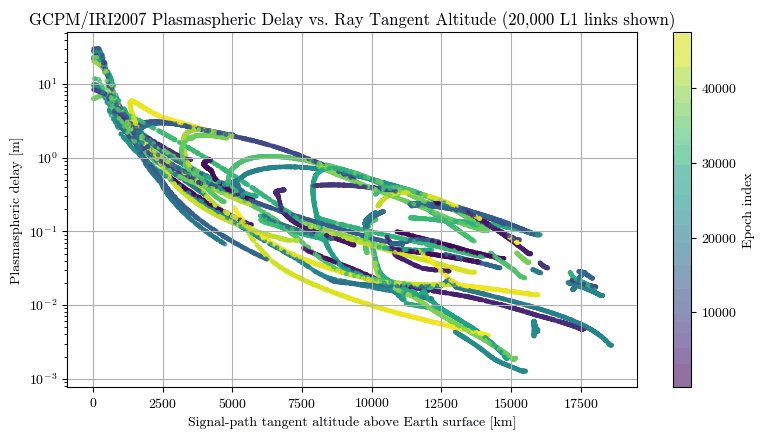

In [5]:
# Sanity check plots only the ray-traced L1 links (the ones carrying a real plasma delay).
# The full-orbit `delays` table has hundreds of thousands of rows -- mostly zero-delay
# L5/Galileo/occulted links -- and scattering all of them overwhelms matplotlib's Agg
# renderer ("OverflowError: Exceeded cell block limit"). Filter to L1, non-occulted, and cap
# the marker count.
plot_df = delays[(delays["frequency"] == "L1") & (delays["tangent_altitude_m"] >= 0.0)]
plot_df = plot_df[
    plot_df[["tangent_altitude_m", "ionosphere_plasma_delay_m"]].notna().all(axis=1)
]
MAX_MARKERS = 20000
if len(plot_df) > MAX_MARKERS:
    plot_df = plot_df.sample(MAX_MARKERS, random_state=0)

fig, ax = plt.subplots(figsize=(8, 4.5))
sc = ax.scatter(
    plot_df["tangent_altitude_m"] / 1e3,
    plot_df["ionosphere_plasma_delay_m"],
    s=6,
    c=plot_df["epoch_index"],
    cmap="viridis",
    alpha=0.6,
)
ax.set_xlabel("Signal-path tangent altitude above Earth surface [km]")
ax.set_ylabel("Plasmaspheric delay [m]")
ax.set_title(
    f"GCPM/IRI2007 Plasmaspheric Delay vs. Ray Tangent Altitude "
    f"({len(plot_df):,} L1 links shown)"
)
plt.colorbar(sc, ax=ax, label="Epoch index")
ax.grid(True)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 4. Run the EKF

`sim.run()` reads `config.delays_file` (since `plasma.simulate_truth=True`), builds noisy
truth pseudorange, Doppler, and TDCP observations, and runs the UDU stochastic-cloning EKF
(because `use_tdcp=True`) over the full receiver-app schedule. It writes
`trajectory_mc0.csv` and `summary.csv` under `config.output_dir` and returns one
`LunarGnssODTSSummary` per Monte Carlo run.

In [6]:
t0 = time.time()
traj_file = Path(cfg.output_dir) / "trajectory_mc0.csv"
if traj_file.exists():
    print(f"Reusing cached trajectory: {traj_file}")
else:
    print(f"Running the simulation (trajectory will be saved to {traj_file})...")
    sim.run()
    print(f"run() took {time.time() - t0:.1f} s")

    summary = sim.get_summaries()[0]
    print(f"Final position error:    {summary.final_position_error_m:8.3f} m")
    print(
        f"Final velocity error:    {summary.final_velocity_error_mps * 1e3:8.3f} mm/s"
    )
    print(f"Final clock bias error:  {summary.final_clock_bias_error_m * 1e2:8.3f} cm")
    print(
        f"Final clock drift error: {summary.final_clock_drift_error_mps * 1e3:8.3f} mm/s"
    )
    print(f"RMS position error:      {summary.rms_position_error_m:8.3f} m")
    print(f"RMS velocity error:      {summary.rms_velocity_error_mps * 1e3:8.3f} mm/s")
    if cfg.estimate_srp_coefficient:
        srp_est = cfg.srp_coeff_truth_m2_kg + summary.final_srp_coeff_error_m2_kg
        print(
            f"Final SRP coeff est:     {srp_est * 1e3:8.3f} e-3 m^2/kg "
            f"(truth {cfg.srp_coeff_truth_m2_kg * 1e3:.3f}e-3, "
            f"err {summary.final_srp_coeff_error_m2_kg * 1e3:+.3f}e-3)"
        )

traj = pd.read_csv(Path(cfg.output_dir) / "trajectory_mc0.csv")
traj["t_min"] = traj["t"] / 60.0
traj["t_hr"] = traj["t"] / 3600.0
traj.head()

Reusing cached trajectory: /Users/keidaiiiyama/Documents/sw_navlab/LuPNT/output/python_examples/ex6_gnss_odts_data/trajectory_mc0.csv


,mc,t,receiver_clock_s,pos_error_m,vel_error_mps,x_error_m,y_error_m,z_error_m,vx_error_mps,vy_error_mps,...,clock_bias_3sigma_m,clock_drift_3sigma_mps,srp_coeff_est_m2_kg,srp_coeff_error_m2_kg,srp_coeff_3sigma_m2_kg,num_channels,num_tracked_satellites,num_measurements,t_min,t_hr
0,0,0,0.000002,148.575,0.055848,-45.0541,-141.190,-10.4900,-0.016700,0.053267,...,285.485,0.00899,0.000232,-0.001768,0.003,3,3,6,0.000000,0.000000
1,0,1,1.000000,141.378,0.047135,-60.4563,-127.074,13.5935,-0.020679,0.041830,...,284.989,0.00899,0.000232,-0.001768,0.003,3,3,12,0.016667,0.000278
2,0,2,2.000000,139.880,0.039700,-62.1117,-124.598,13.5663,-0.010509,0.035113,...,284.822,0.00899,0.000232,-0.001768,0.003,3,3,12,0.033333,0.000556
3,0,3,3.000000,139.027,0.039698,-63.7147,-122.700,14.6167,-0.008590,0.034327,...,284.738,0.00899,0.000232,-0.001768,0.003,3,3,12,0.050000,0.000833
4,0,4,4.000000,141.691,0.039468,-61.4987,-126.490,17.1602,-0.009607,0.031750,...,284.687,0.00899,0.000232,-0.001768,0.003,3,3,12,0.066667,0.001111


## 5. Position Error in the RTN Frame, with 3-sigma Bounds

`r`/`t`/`n` are the radial/transverse/normal components of the position error; the shaded
band is the filter's own formal 3-sigma envelope (`*_3sigma_m` columns), computed from the
EKF covariance at each epoch.

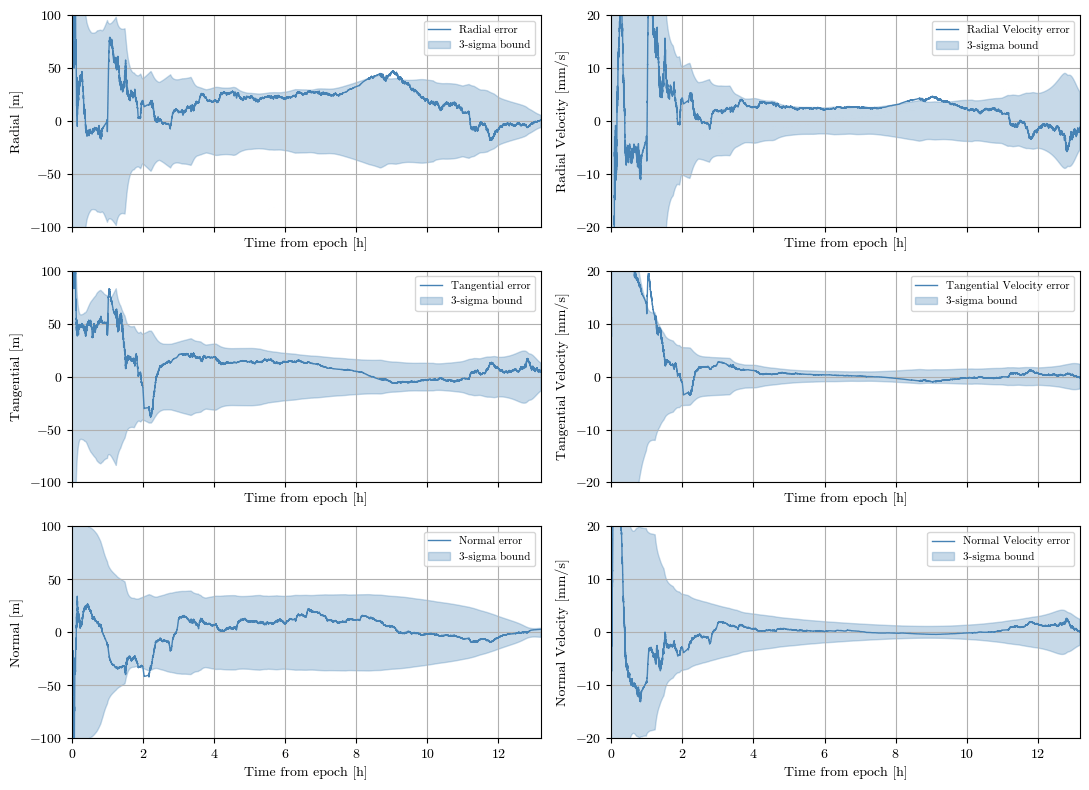

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(11, 8), sharex=True)
for row, (key, name) in zip(
    [0, 1, 2, 0, 1, 2], [("r", "Radial"), ("t", "Tangential"), ("n", "Normal"), ("rdot", "Radial Velocity"), ("tdot", "Tangential Velocity"), ("ndot", "Normal Velocity")]
):
    if key in ["r", "t", "n"]:
        col = 0
        suffix = "m"
        axes[row, col].set_ylim(-100, 100)
        scale = 1.0
        axes[row, col].set_ylabel(f"{name} [m]")
        axes[row, col].grid(True)
    else:
        col = 1
        suffix = "mps"
        axes[row, col].set_ylim(-20, 20)
        scale = 1000.0
        axes[row, col].set_ylabel(f"{name} [mm/s]")
        axes[row, col].grid(True)
    
    err = traj[f"{key}_error_{suffix}"]
    sig = traj[f"{key}_3sigma_{suffix}"]
    axes[row, col].plot(traj["t_hr"], err * scale, color="steelblue", lw=1.0, label=f"{name} error")
    axes[row, col].fill_between(
        traj["t_hr"], -sig * scale, sig * scale, color="steelblue", alpha=0.3, label="3-sigma bound"
    )
    axes[row, col].legend(loc="upper right", fontsize=8)
    axes[row, col].set_xlabel("Time from epoch [h]")
    axes[row, col].set_xlim(0, traj["t_hr"].max())
plt.tight_layout()
plt.show()

## 6. Clock Bias and Drift Error

Clock errors are reported in range-equivalent units (`c * dt`), matching the pseudorange
measurement's own units.

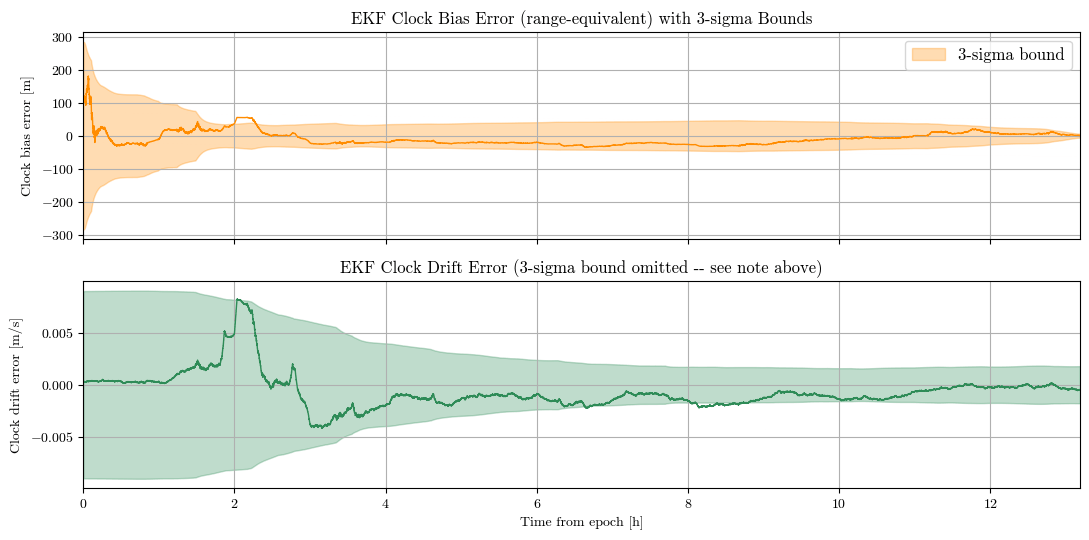

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)

axes[0].plot(traj["t_hr"], traj["clock_bias_error_m"], color="darkorange", lw=1.0)
axes[0].fill_between(
    traj["t_hr"],
    -traj["clock_bias_3sigma_m"],
    traj["clock_bias_3sigma_m"],
    color="darkorange",
    alpha=0.3,
    label="3-sigma bound",
)
axes[0].set_ylabel("Clock bias error [m]")
axes[0].set_title("EKF Clock Bias Error (range-equivalent) with 3-sigma Bounds")
axes[0].legend(loc="upper right", fontsize=12)
axes[0].grid(True)

# No 3-sigma shading here -- see the markdown note above on why clock_drift_3sigma_mps
# is not trustworthy (covariance conditioning, unrelated to TDCP).
axes[1].plot(traj["t_hr"], traj["clock_drift_error_mps"], color="seagreen", lw=1.0)
axes[1].fill_between(
    traj["t_hr"],
    -traj["clock_drift_3sigma_mps"],
    traj["clock_drift_3sigma_mps"],
    color="seagreen",
    alpha=0.3,
    label="3-sigma bound (not trustworthy -- see note above)",
)
axes[1].set_ylabel("Clock drift error [m/s]")
axes[1].set_title("EKF Clock Drift Error (3-sigma bound omitted -- see note above)")
axes[1].set_xlabel("Time from epoch [h]")
axes[1].set_xlim(0, traj["t_hr"].max())
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6b. Solar Radiation Pressure Coefficient Estimate

With `estimate_srp_coefficient=True`, the filter carries the SRP coefficient (`Cr*A/m`)
as a 9th state alongside orbit and clock. Its sensitivity is propagated **analytically**:
`LunarGnssODTSSimulation` calls `NBodyDynamics::PropagateWithParams` on the C++
`JointOrbitClockState` with an SRP `ParamState`, so the epoch-to-epoch state-transition
matrix already contains the `∂x/∂(Cr*A/m)` param-partial block (`stm_param`) — there is
**no numerical differencing** of the dynamics to build the Jacobian.

The truth ELFO is perturbed with `srp_coeff_truth_m2_kg` while the filter starts from a
deliberately biased `initial_srp_coeff_m2_kg`; the plot below shows the estimate pulling
toward the dashed truth line. SRP is only weakly observable over a single orbit (it acts
as a slow, mostly along-track acceleration), so convergence is gradual and the formal
3-sigma band shrinks slowly — one orbital period is about the shortest useful arc for
seeing it move at all.

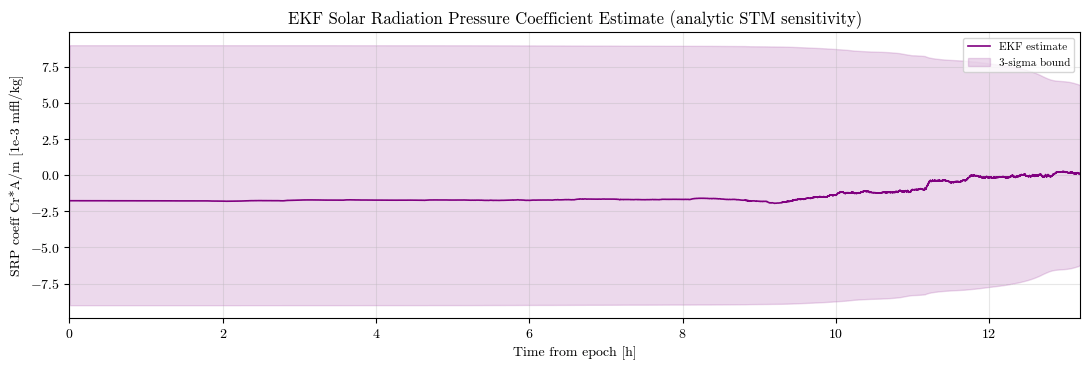

In [9]:
est = traj["srp_coeff_est_m2_kg"] * 1e3  # 1e-3 m^2/kg
true_val = cfg.srp_coeff_truth_m2_kg * 1e3  # 1e-3 m^2/kg
sig = traj["srp_coeff_3sigma_m2_kg"] * 1e3

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(traj["t_hr"], est - true_val, color="purple", lw=1.2, label="EKF estimate")
ax.fill_between(
    traj["t_hr"],
    - 3 *sig,
    3 * sig,
    color="purple",
    alpha=0.15,
    label="3-sigma bound",
)
ax.set_xlabel("Time from epoch [h]")
ax.set_ylabel("SRP coeff Cr*A/m [1e-3 m²/kg]")
ax.set_title(
    "EKF Solar Radiation Pressure Coefficient Estimate (analytic STM sensitivity)"
)
ax.set_xlim(0, traj["t_hr"].max())
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6c. Error Distribution (True − Estimated)

Histograms of the per-epoch ephemeris error over the full run — radial / transverse /
normal position components and the range-equivalent clock bias — each annotated with mean,
standard deviation, and RMS. A well-tuned filter centers each distribution near zero with a
spread consistent with the 3-sigma envelopes in §5–6. This is the distribution over epochs
of a single Monte Carlo run; raise `cfg.monte_carlo_runs` for a cross-run distribution.

/var/folders/1f/_8g3y5td38n93nph4z3c5d4c0000gn/T/ipykernel_10879/14268039.py:27: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from font(s) cmr10.
  plt.tight_layout()


/Users/keidaiiiyama/Documents/sw_navlab/LuPNT/.pixi/envs/default/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


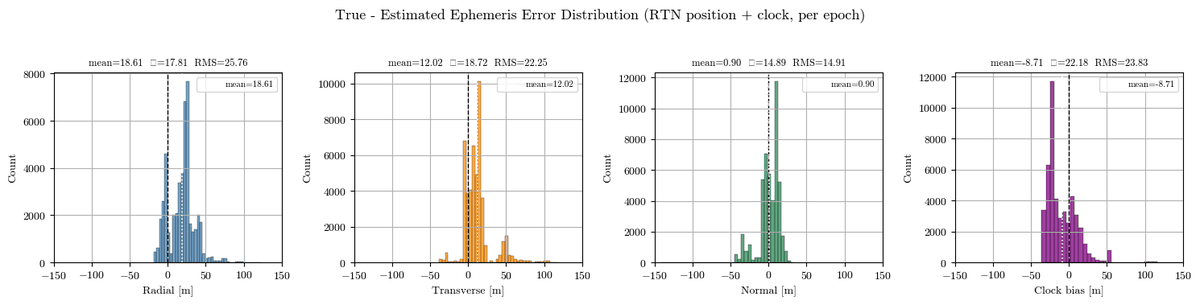

Component             mean       std       RMS  95th |err|
----------------------------------------------------------
Radial [m]          18.610    17.811    25.760      44.164
Transverse [m]      12.023    18.720    22.248      50.955
Normal [m]           0.897    14.887    14.914      32.217
Clock bias [m]      -8.711    22.183    23.832      32.624


In [10]:
dist_cols = [
    ("r_error_m", "Radial [m]", "steelblue"),
    ("t_error_m", "Transverse [m]", "darkorange"),
    ("n_error_m", "Normal [m]", "seagreen"),
    ("clock_bias_error_m", "Clock bias [m]", "purple"),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (col, label, color) in zip(axes, dist_cols):
    data = traj[col].to_numpy()
    mean, std = float(np.mean(data)), float(np.std(data))
    rms = float(np.sqrt(np.mean(data**2)))
    ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor="k", lw=0.3)
    ax.axvline(0.0, color="k", ls="--", lw=1.0)
    ax.axvline(mean, color="white", ls=":", lw=1.2, label=f"mean={mean:.2f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(f"mean={mean:.2f}  σ={std:.2f}  RMS={rms:.2f}", fontsize=9)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True)
    ax.set_xlim(-150, 150)
fig.suptitle(
    "True - Estimated Ephemeris Error Distribution (RTN position + clock, per epoch)",
    y=1.04,
    fontsize=13,
)
plt.tight_layout()
plt.show()

print(f"{'Component':<16}{'mean':>10}{'std':>10}{'RMS':>10}{'95th |err|':>12}")
print("-" * 58)
for col, label, _ in dist_cols:
    d = traj[col].to_numpy()
    print(
        f"{label:<16}{np.mean(d):>10.3f}{np.std(d):>10.3f}{np.sqrt(np.mean(d**2)):>10.3f}"
        f"{np.percentile(np.abs(d), 95):>12.3f}"
    )

## 7. Sidelobe Tracking and TDCP Contribution

`num_tracked_satellites` is the number of distinct GNSS (GPS + Galileo) satellites tracked
via sidelobe reception at each epoch; `num_measurements` is the total measurement-row count
fed to the filter that epoch (pseudorange and Doppler rows plus one TDCP row per
continuously tracked link). The first epoch has no TDCP rows since there is no previous
epoch to difference against.

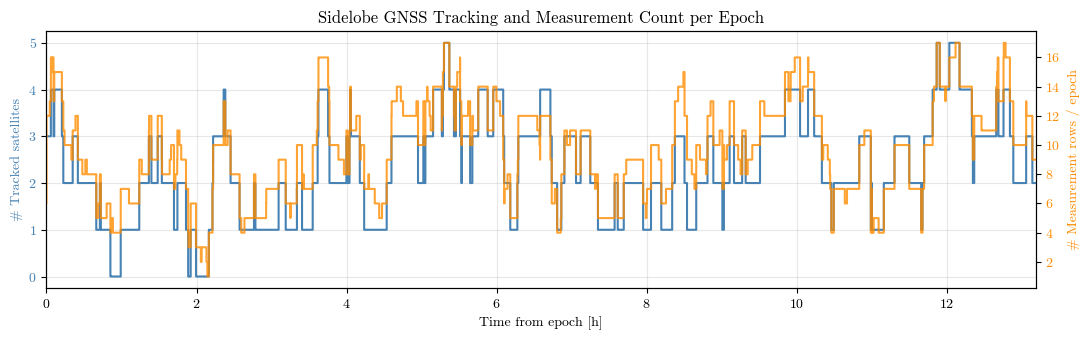

Epochs with at least one TDCP row: 47475/47475


In [11]:
fig, ax1 = plt.subplots(figsize=(11, 3.5))
ax1.step(
    traj["t_hr"],
    traj["num_tracked_satellites"],
    where="post",
    color="steelblue",
    label="Tracked GNSS satellites (sidelobe)",
)
ax1.set_xlabel("Time from epoch [h]")
ax1.set_ylabel("# Tracked satellites", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xlim(0, traj["t_hr"].max())

ax2 = ax1.twinx()
ax2.step(
    traj["t_hr"],
    traj["num_measurements"],
    where="post",
    color="darkorange",
    alpha=0.8,
    label="Measurement rows (pseudorange + Doppler + TDCP)",
)
ax2.set_ylabel("# Measurement rows / epoch", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

ax1.set_title("Sidelobe GNSS Tracking and Measurement Count per Epoch")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_tdcp_epochs = int((traj["num_measurements"] > traj["num_tracked_satellites"]).sum())
print(f"Epochs with at least one TDCP row: {n_tdcp_epochs}/{len(traj)}")

## 8. Summary

This notebook demonstrated LuPNT's full lunar-GNSS ODTS pipeline:

- `LunarGnssODTSConfig` defines both truth generation and estimator tuning for a lunar receiver.
- GNSS sidelobe visibility and $C/N_0$ are precomputed once and cached, separating expensive deterministic geometry from repeated filter runs.
- Plasmaspheric delay is ray-traced at anchor epochs and interpolated to the 1 Hz measurement grid.
- Pseudorange uses a dual-frequency ionosphere-free combination when available; Doppler (range rate) constrains velocity and clock drift within each epoch; TDCP remains single-frequency and is handled with stochastic cloning because it couples epochs.
- The EKF estimates orbit, receiver clock, and the SRP coefficient (`Cr*A/m`) with analytic dynamics sensitivities.